# To demonstrate the model can be improved if there's structure in residuals

## Experiment Setup

We will generate a "Ground Truth" dataset where we know the exact maximum potential of the model.

1. The Signal: A curve (Quadratic function $y = x^2$).
2. The Noise: Random scatter added to the data. This represents real-world messiness (measurement error, hidden variables). This noise sets the "Ceiling" of your $R^2$.We will then fit two models and compare their Residual Plots.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score


In [21]:
help(r2_score)

Help on function r2_score in module sklearn.metrics._regression:

r2_score(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average', force_finite=True)
    :math:`R^2` (coefficient of determination) regression score function.
    
    Best possible score is 1.0 and it can be negative (because the
    model can be arbitrarily worse). In the general case when the true y is
    non-constant, a constant model that always predicts the average y
    disregarding the input features would get a :math:`R^2` score of 0.0.
    
    In the particular case when ``y_true`` is constant, the :math:`R^2` score
    is not finite: it is either ``NaN`` (perfect predictions) or ``-Inf``
    (imperfect predictions). To prevent such non-finite numbers to pollute
    higher-level experiments such as a grid search cross-validation, by default
    these cases are replaced with 1.0 (perfect predictions) or 0.0 (imperfect
    predictions) respectively. You can set ``force_finite`` to ``False`` to
    

In [22]:
np.random.seed(73)
X = np.linspace(-3,3,100).reshape(-1,1)

#Signal

y = X**2 + np.random.normal(0,1.5, size=X.shape)

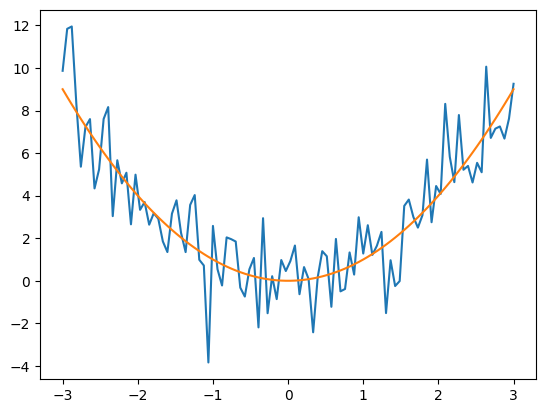

In [23]:
plt.plot(X,y)
plt.plot(X,X**2)

plt.show()

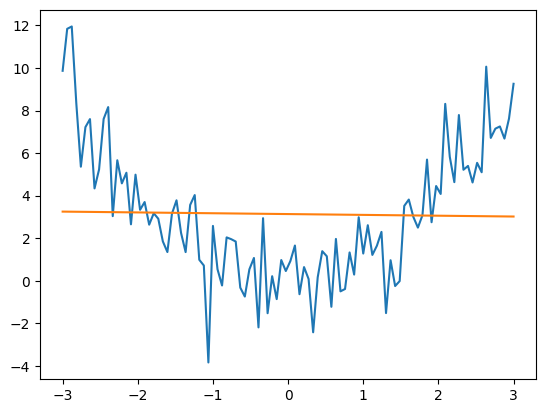

In [24]:
# Low capacity model : linear model 

model_a = LinearRegression()
model_a.fit(X, y)
y_pred_a = model_a.predict(X)
residuals_a = y - y_pred_a
r2_a = r2_score(y, y_pred_a)

plt.cla()
plt.plot(X, y)
plt.plot(X, y_pred_a)
plt.show()



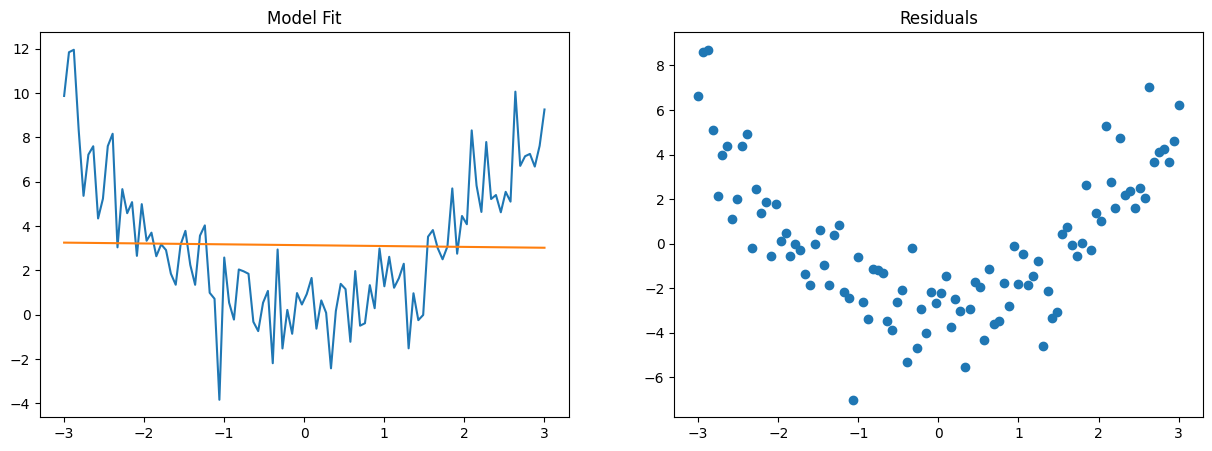

In [39]:
plt.close()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(X,y)
axes[0].plot(X,y_pred_a)
axes[1].scatter(X, residuals_a)
axes[0].set_title("Model Fit")
axes[1].set_title("Residuals")

plt.show()

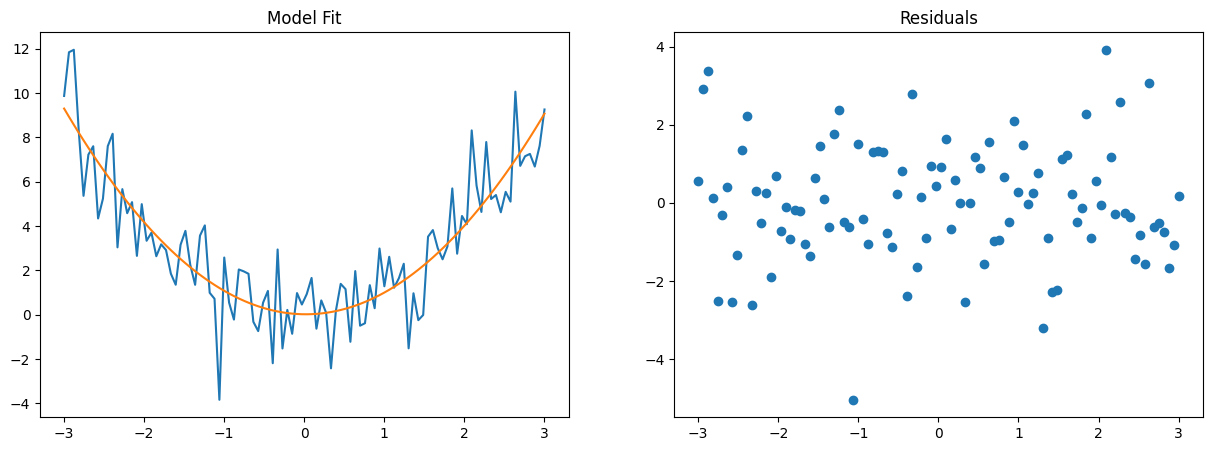

In [40]:
# High capacity quadratic model 

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model_b = LinearRegression()
model_b.fit(X_poly, y)
y_pred_b = model_b.predict(X_poly)
residuals_b = y - y_pred_b
r2_b = r2_score(y, y_pred_b)

plt.close()

fig, axes = plt.subplots( 1, 2 , figsize=(15,5))
axes[0].plot(X, y)
axes[0].plot(X, y_pred_b)
axes[1].scatter(X, residuals_b)
axes[0].set_title("Model Fit")
axes[1].set_title("Residuals")
plt.show()


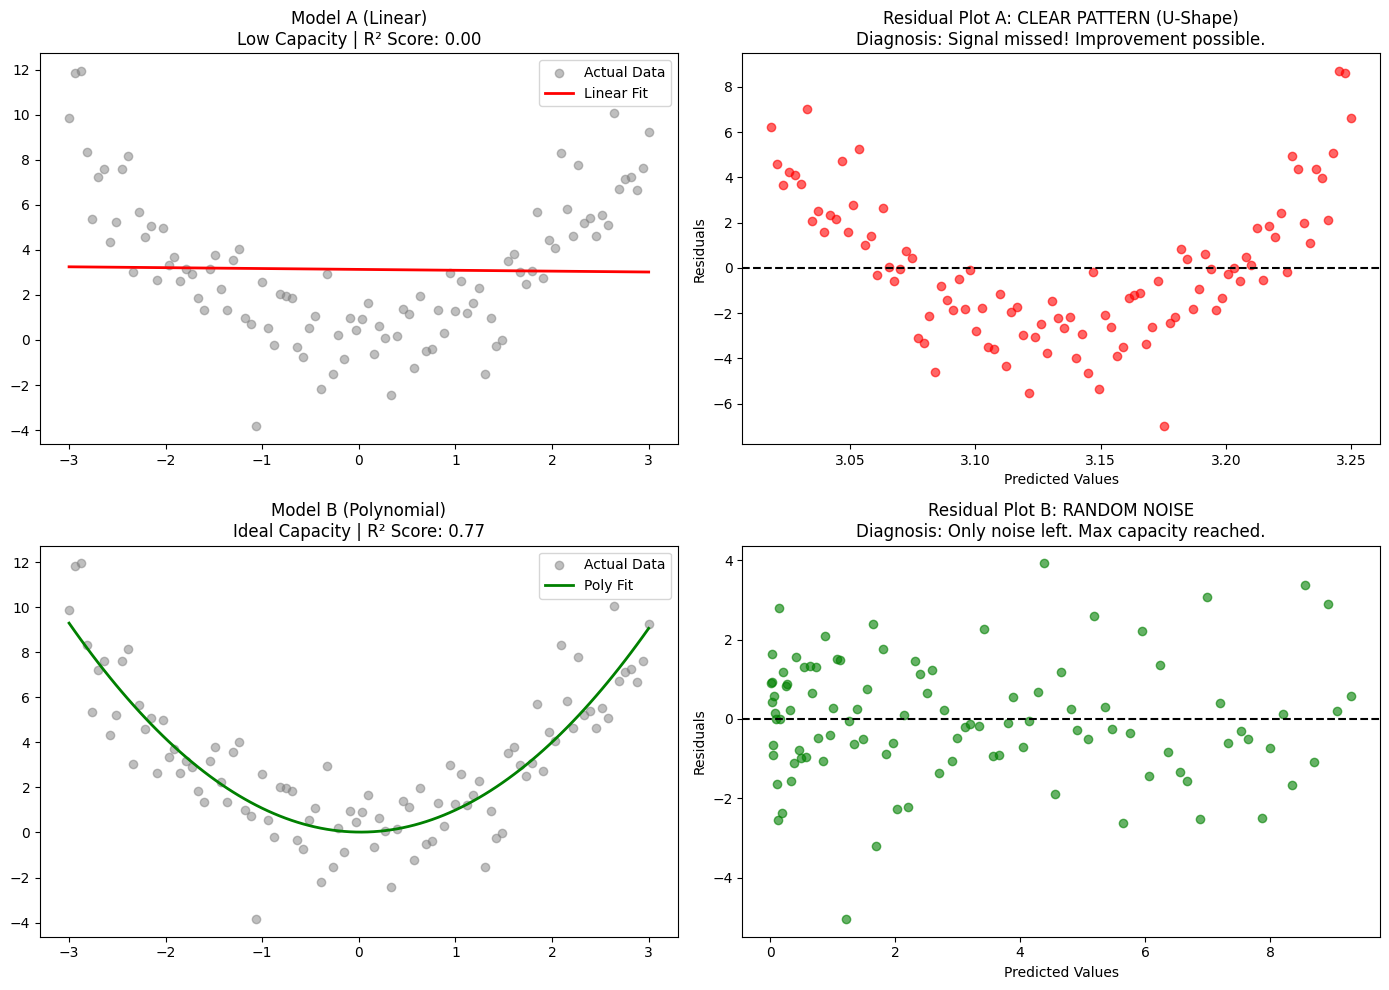

In [26]:
# Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
axes[0, 0].plot(X, y_pred_a, color='red', linewidth=2, label='Linear Fit')
axes[0, 0].set_title(f"Model A (Linear)\nLow Capacity | R² Score: {r2_a:.2f}")
axes[0, 0].legend()

# Plot A2: Residuals for Model A
axes[0, 1].scatter(y_pred_a, residuals_a, color='red', alpha=0.6)
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set_title("Residual Plot A: CLEAR PATTERN (U-Shape)\nDiagnosis: Signal missed! Improvement possible.")
axes[0, 1].set_xlabel("Predicted Values")
axes[0, 1].set_ylabel("Residuals")

# Plot B1: The Polynomial Fit
axes[1, 0].scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
axes[1, 0].plot(X, y_pred_b, color='green', linewidth=2, label='Poly Fit')
axes[1, 0].set_title(f"Model B (Polynomial)\nIdeal Capacity | R² Score: {r2_b:.2f}")
axes[1, 0].legend()

# Plot B2: Residuals for Model B
axes[1, 1].scatter(y_pred_b, residuals_b, color='green', alpha=0.6)
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title("Residual Plot B: RANDOM NOISE\nDiagnosis: Only noise left. Max capacity reached.")
axes[1, 1].set_xlabel("Predicted Values")
axes[1, 1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()